#Rede Neural feita na Mão

##Criando um dataset

Text(0, 0.5, 'X2')

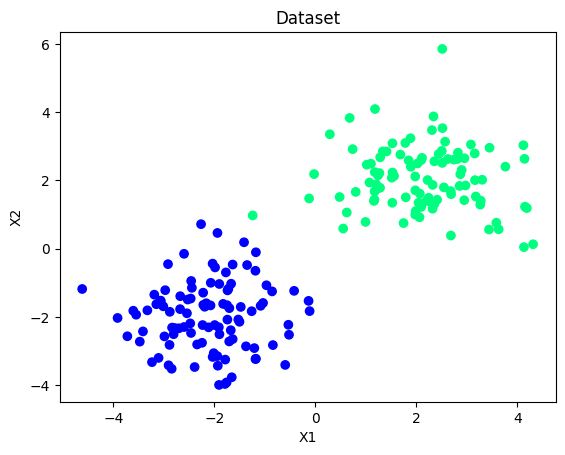

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 2D data points in two classes
np.random.seed(42)
N = 100
X_class0 = np.random.randn(N, 2) + np.array([-2, -2])
X_class1 = np.random.randn(N, 2) + np.array([2, 2])
X = np.vstack([X_class0, X_class1])
y = np.array([0] * N + [1] * N).reshape(-1, 1)  # Labels: 0 or 1

# visualizando os dados
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="winter")
plt.title("Dataset")
plt.xlabel("X1")
plt.ylabel("X2")

##Inicializando os parâmetros

In [2]:
# Network architecture: 2 input nodes → 3 hidden → 1 output
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))


# Initialize weights and biases
np.random.seed(0)
W1 = np.random.randn(2, 3)  # 2 inputs → 3 hidden neurons
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1)  # 3 hidden → 1 output
b2 = np.zeros((1, 1))

##Treinamento

In [3]:
# Training loop
learning_rate = 0.1
for epoch in range(1000):
    # Forward pass
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    y_pred = sigmoid(z2)

    # Loss (Mean Squared Error)
    loss = np.mean((y_pred - y) ** 2)

    # Backward pass
    dz2 = (y_pred - y) * sigmoid_derivative(z2)
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * sigmoid_derivative(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Update weights
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.1710
Epoch 100, Loss: 0.0007
Epoch 200, Loss: 0.0004
Epoch 300, Loss: 0.0003
Epoch 400, Loss: 0.0002
Epoch 500, Loss: 0.0002
Epoch 600, Loss: 0.0001
Epoch 700, Loss: 0.0001
Epoch 800, Loss: 0.0001
Epoch 900, Loss: 0.0001


##Predição e avaliação

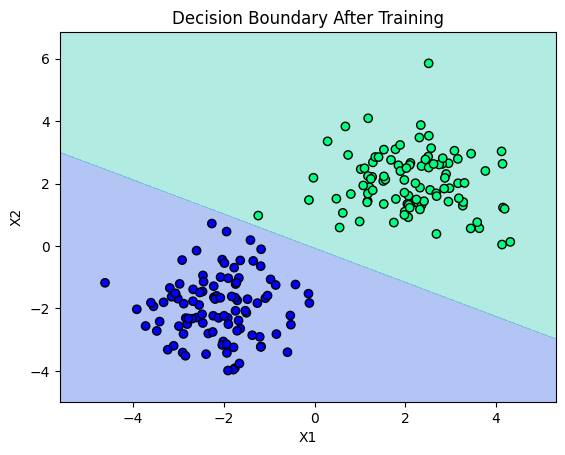

In [4]:
# Forward function using the learned weights
def predict(X):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    return sigmoid(z2)


# Create a grid of points over the input space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict probabilities for each point in the grid
probs = predict(grid).reshape(xx.shape)

# Plot decision boundary and data
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], cmap="winter", alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap="winter", edgecolors="k")
plt.title("Decision Boundary After Training")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

#Rede Neural com Keras

##Treinamento

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# Define the model
model = Sequential(
    [Dense(3, input_dim=2, activation="sigmoid"), Dense(1, activation="sigmoid")]
)

# Compile the model
model.compile(optimizer=SGD(learning_rate=0.1), loss="mse")

# Train
model.fit(X, y, epochs=100, verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2018  
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1907 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1804 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1718 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1639 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1560 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1484 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1414 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1345 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1279 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1216 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1156 
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1101 
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1045 
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0994 
Epoch 16/100
7/7 ━━━━━━━━━━━━━

##Predição e avaliação

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


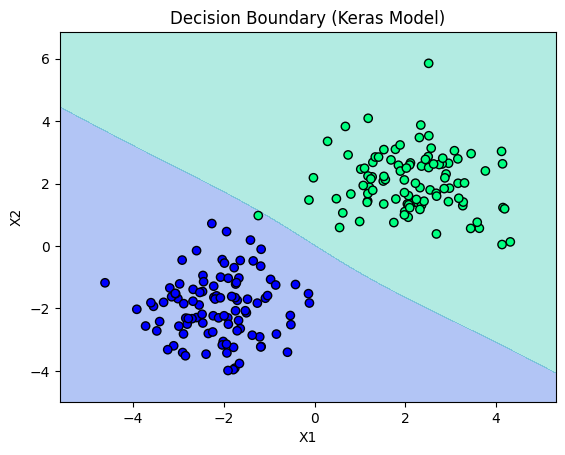

In [6]:
# Create a dense grid of points in the input space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict probabilities for each point using the trained model
probs = model.predict(grid).reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], cmap="winter", alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap="winter", edgecolors="k")
plt.title("Decision Boundary (Keras Model)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

#Rede Neural com Pytorch

##Treinamento

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Define model
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 3)
        self.output = nn.Linear(3, 1)

    def forward(self, x):
        x = torch.sigmoid(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x


model = Net()
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.MSELoss()

# Training loop
for epoch in range(100):
    y_pred = model(X_tensor)
    loss = criterion(y_pred, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.2547
Epoch 10, Loss: 0.2394
Epoch 20, Loss: 0.2253
Epoch 30, Loss: 0.2122
Epoch 40, Loss: 0.1999
Epoch 50, Loss: 0.1881
Epoch 60, Loss: 0.1768
Epoch 70, Loss: 0.1660
Epoch 80, Loss: 0.1555
Epoch 90, Loss: 0.1455


##Predição e Avaliação

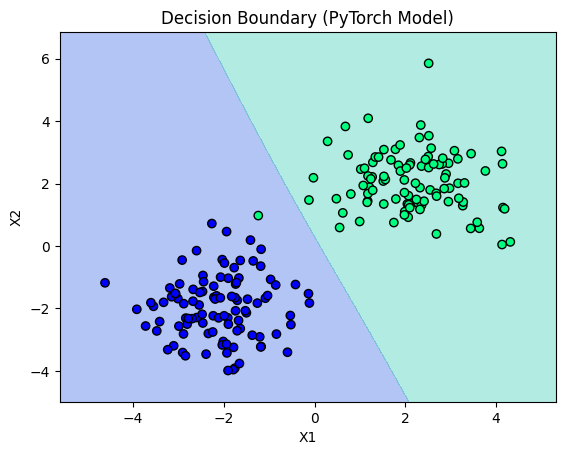

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Create a dense grid of points over the input space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

# Convert grid to PyTorch tensor and predict
grid_tensor = torch.tensor(grid)
with torch.no_grad():
    preds = model(grid_tensor).numpy().reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, preds, levels=[0, 0.5, 1], cmap="winter", alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap="winter", edgecolors="k")
plt.title("Decision Boundary (PyTorch Model)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()